#TASK 2 CUSTOMER SEGMENTATION ANALYSIS

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


##LOADING AND INSPECTING DATASET

In [7]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]

In [8]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397924.000000,397924,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.420210,NaN,22.096788,1713.169877


##OBSERVATION
The dataset contains transactional records where each row represents a product purchase. Key columns include InvoiceNo, Quantity, UnitPrice, CustomerID, and Country. Some missing values were initially present in the CustomerID column.

##HANDELING  MISSING AND INCONSISTENT DATA

In [10]:
before = df.shape[0]

df = df.dropna(subset=['CustomerID'])

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Removed rows:", before - after)


Rows before: 397924
Rows after: 397924
Removed rows: 0


##OBSERVATION
After removing missing CustomerID values and filtering out negative quantities, the dataset contains only valid customer transactions. No rows were removed during missing value handling, indicating that the dataset already contained valid CustomerID values and required minimal cleaning.

##DESCRIPTIVE STATISTICS

In [17]:
print("Average Purchase Value:", avg_purchase)

print("\nPurchase Frequency (Top 5):")
print(purchase_freq.head())

print("\nCustomer Lifetime Value (Top 5):")
print(clv.head())

Average Purchase Value: 22.394748504739596

Purchase Frequency (Top 5):
CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

Customer Lifetime Value (Top 5):
CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: TotalPrice, dtype: float64


##OBSERVATION
The average purchase value is approximately 22.39, indicating moderate transaction sizes. Purchase frequency varies significantly across customers, with some customers making only one purchase while others make multiple transactions. Customer Lifetime Value (CLV) shows a highly skewed distribution, where a small number of customers contribute a large portion of total revenue. This confirms the typical Pareto principle (80/20 rule) in e-commerce.

##FEATURE SELECTION

In [19]:
print("RFM Table (Top 5 rows):")
print(rfm.head())

print("\nRFM Summary:")
print(rfm.describe())

RFM Table (Top 5 rows):
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40

RFM Summary:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     307.245000
50%      51.000000     2.000000     674.450000
75%     142.000000     5.000000    1661.640000
max     374.000000   210.000000  280206.020000


##OBSERVATION
The RFM analysis highlights strong variability in customer behavior. A small group of customers has low recency, high frequency, and high monetary value, identifying them as loyal and high-value customers. In contrast, many customers have high recency, low frequency, and low spending, indicating inactive or occasional buyers. This imbalance shows that revenue is concentrated among a limited number of customers.


##DATA NORMALIZATION


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Select RFM columns
rfm_values = rfm[['Recency', 'Frequency', 'Monetary']]

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform
rfm_scaled = scaler.fit_transform(rfm_values)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# Show output
print(rfm_scaled.head())
print("\nSummary:\n", rfm_scaled.describe())

    Recency  Frequency  Monetary
0  0.871314   0.000000  0.275453
1  0.002681   0.028708  0.015382
2  0.198391   0.014354  0.006414
3  0.048257   0.000000  0.006272
4  0.828418   0.000000  0.001193

Summary:
            Recency    Frequency     Monetary
count  4339.000000  4339.000000  4339.000000
mean      0.245357     0.015655     0.007330
std       0.268123     0.036868     0.032077
min       0.000000     0.000000     0.000000
25%       0.045576     0.000000     0.001096
50%       0.134048     0.004785     0.002407
75%       0.378016     0.019139     0.005930
max       1.000000     1.000000     1.000000


##OBSERVATION
After normalization, all features (Recency, Frequency, Monetary) are scaled between 0 and 1, ensuring no single feature dominates the clustering process. Most customers have low frequency and low monetary values, while only a few customers have high values, reinforcing the presence of high-value customer segments.

##ELBOW METHOD

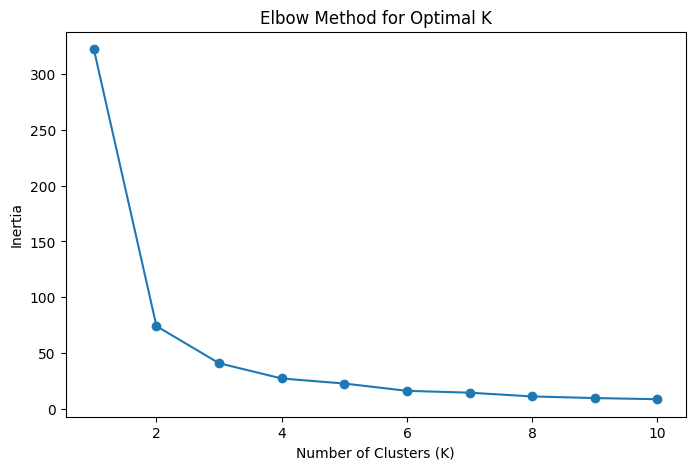

K=1, Inertia=322.2178951676161
K=2, Inertia=74.11734987114905
K=3, Inertia=40.83711491830402
K=4, Inertia=27.18254795620217
K=5, Inertia=22.655870920958524
K=6, Inertia=16.10824323233756
K=7, Inertia=14.453931166438524
K=8, Inertia=11.089396732584403
K=9, Inertia=9.639600844652865
K=10, Inertia=8.598531014390911


In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia values
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# Print values
for k, val in zip(K_range, inertia):
    print(f"K={k}, Inertia={val}")

##OBSERVATION

The Elbow Method shows a sharp decrease in inertia up to K = 3 or 4, after which the improvement becomes gradual. This indicates that the optimal number of clusters is 4, as adding more clusters does not significantly improve model performance.

##APPLY K-MEANS CLUSTERS

In [24]:
from sklearn.cluster import KMeans

# Choose optimal K (use 3 or 4 based on elbow)
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit model
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Show first rows
print(rfm.head())

# Count customers in each cluster
print("\nCustomers per cluster:\n", rfm['Cluster'].value_counts())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        2
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        3

Customers per cluster:
 Cluster
0    2215
2    1029
1     598
3     497
Name: count, dtype: int64


##OBSERVATION
Customers were successfully segmented into 4 clusters, with varying group sizes. One cluster contains the majority of customers, while others represent more specific behavioral groups such as high-value or inactive customers.

##CLUSTER PROFILING

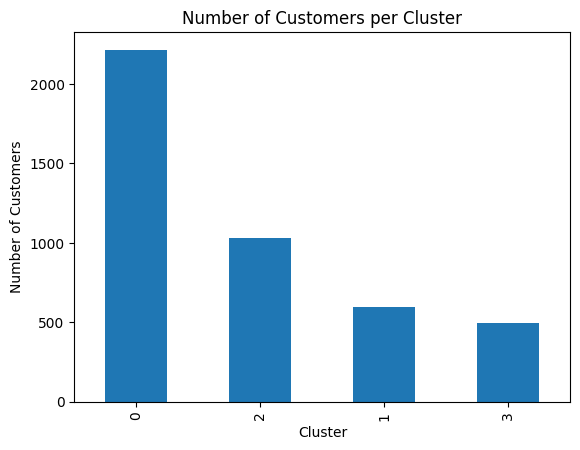

In [27]:
rfm['Cluster'].value_counts().plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

##OBSERVATION
The bar chart shows an uneven distribution of customers across clusters, where one cluster contains the majority of customers, indicating a large segment of low-to-moderate value customers. In contrast, high-value customer clusters are smaller in size but contribute significantly to overall revenue. This highlights that a small group of customers plays a crucial role in business profitability, while the majority require engagement strategies to increase their value.



##VISUALIZATION

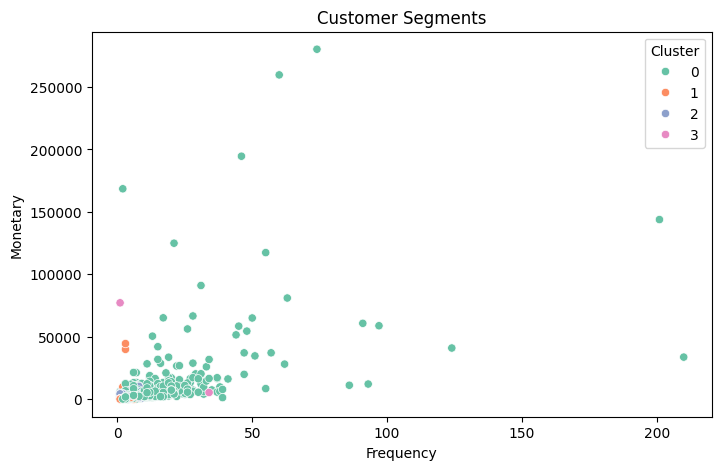

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x=rfm['Frequency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='Set2')

plt.title('Customer Segments')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

##OBSERVATIONS

The scatter plot shows clear separation between clusters, especially when comparing Frequency and Monetary values. High-value customers are distinctly visible with higher spending and purchase frequency, while low-value customers are grouped near the origin.
The clusters are well-separated, showing that K-Means successfully identified distinct customer segments based on purchasing behavior.



##Final Insights & Marketing Strategy

 The analysis confirms that customer purchasing behavior is highly imbalanced, where a small group of high-value customers contributes significantly to overall revenue. By leveraging customer segmentation, businesses can implement targeted marketing strategies to improve retention, increase engagement, and maximize profitability. Focusing on high-value customers while converting low-value and at-risk customers can lead to sustainable business growth.



##Final Business Conclusion

A small percentage of customers drives the majority of revenue, making it crucial to prioritize retention of high-value customers while also nurturing and re-engaging other segments to maximize overall profitability.